In [1]:
# Necessary libraries and dataset load

# Section 1:

import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Section 2:

from bs4 import BeautifulSoup
import requests
import matplotlib.pyplot as plt

# load the csv

file_path = "pokemon.csv"
df = pd.read_csv(file_path)


# Section 3:

import requests
import numpy as np
from collections import defaultdict
import sqlite3

In [2]:
# Section 1:

# Data transformation 1:
# Removal of extra symbols from column headers simplifies headers

# Clean column headers by removing extra symbols

df.columns = df.columns.str.replace(r'[^a-zA-Z0-9]', '', regex=True)

# Display cleaned column headers

print(df.columns.tolist())

['abilities', 'againstbug', 'againstdark', 'againstdragon', 'againstelectric', 'againstfairy', 'againstfight', 'againstfire', 'againstflying', 'againstghost', 'againstgrass', 'againstground', 'againstice', 'againstnormal', 'againstpoison', 'againstpsychic', 'againstrock', 'againststeel', 'againstwater', 'attack', 'baseeggsteps', 'basehappiness', 'basetotal', 'capturerate', 'classfication', 'defense', 'experiencegrowth', 'heightm', 'hp', 'japanesename', 'name', 'percentagemale', 'pokedexnumber', 'spattack', 'spdefense', 'speed', 'type1', 'type2', 'weightkg', 'generation', 'islegendary']


In [3]:
# Data transformation 2: 
# Removal of leading zeros from all row entries

# Function to remove leading zeros from all string and numerical entries

def remove_all_leading_zeros(val):
    try:
        val_str = str(val)
        val_str_no_zeros = val_str.lstrip('0')
        if val_str_no_zeros.replace('.', '', 1).isdigit():
            return int(val_str_no_zeros) if '.' not in val_str_no_zeros else float(val_str_no_zeros)
        return val_str_no_zeros
    except Exceptiopn:
        return val

# Apply to the entire DataFrame

for col in df.columns:
    df[col] = df[col].map(remove_all_leading_zeros)

# Display

print(df.head())

                     abilities  againstbug  againstdark  againstdragon  \
0  ['Overgrow', 'Chlorophyll']         1.0          1.0            1.0   
1  ['Overgrow', 'Chlorophyll']         1.0          1.0            1.0   
2  ['Overgrow', 'Chlorophyll']         1.0          1.0            1.0   
3     ['Blaze', 'Solar Power']         0.5          1.0            1.0   
4     ['Blaze', 'Solar Power']         0.5          1.0            1.0   

   againstelectric  againstfairy  againstfight  againstfire  againstflying  \
0              0.5           0.5           0.5          2.0            2.0   
1              0.5           0.5           0.5          2.0            2.0   
2              0.5           0.5           0.5          2.0            2.0   
3              1.0           0.5           1.0          0.5            1.0   
4              1.0           0.5           1.0          0.5            1.0   

   againstghost  ...  percentagemale  pokedexnumber  spattack  spdefense  \
0         

In [4]:
# Data transformation 3:
# Removal of the classification and abilities columns, as it is unnecessary to research my project topic

# Remove 'classification' and 'abilities' columns

df = df.drop(columns=['classfication', 'abilities'])

# Display remaining columns

print("Remaining Columns:")
print(df.columns.tolist())

Remaining Columns:
['againstbug', 'againstdark', 'againstdragon', 'againstelectric', 'againstfairy', 'againstfight', 'againstfire', 'againstflying', 'againstghost', 'againstgrass', 'againstground', 'againstice', 'againstnormal', 'againstpoison', 'againstpsychic', 'againstrock', 'againststeel', 'againstwater', 'attack', 'baseeggsteps', 'basehappiness', 'basetotal', 'capturerate', 'defense', 'experiencegrowth', 'heightm', 'hp', 'japanesename', 'name', 'percentagemale', 'pokedexnumber', 'spattack', 'spdefense', 'speed', 'type1', 'type2', 'weightkg', 'generation', 'islegendary']


In [7]:
# Data transformation 4:
# Removal of the 'japanesename' column as it is redundant and adds unnecessary complexity to the dataset when researching my project topic

# Remove the 'japanese_name' column

df = df.drop(columns=['japanesename'])

# Display
print("Remaining Columns:")
print(df.columns.tolist())

Remaining Columns:
['againstbug', 'againstdark', 'againstdragon', 'againstelectric', 'againstfairy', 'againstfight', 'againstfire', 'againstflying', 'againstghost', 'againstgrass', 'againstground', 'againstice', 'againstnormal', 'againstpoison', 'againstpsychic', 'againstrock', 'againststeel', 'againstwater', 'attack', 'baseeggsteps', 'basehappiness', 'basetotal', 'capturerate', 'defense', 'experiencegrowth', 'heightm', 'hp', 'name', 'percentagemale', 'pokedexnumber', 'spattack', 'spdefense', 'speed', 'type1', 'type2', 'weightkg', 'generation', 'islegendary']


In [8]:
# Data transformation 5:
# Searches for and fills all missing values

# Fill missing values, 0 for numerical and 'Unknown' for string entries

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna('Unknown')
    else:
        df[col] = df[col].fillna(0)

# Confirm no missing values remain

print("Remaining missing values:")
print(df.isnull().sum())

Remaining missing values:
againstbug          0
againstdark         0
againstdragon       0
againstelectric     0
againstfairy        0
againstfight        0
againstfire         0
againstflying       0
againstghost        0
againstgrass        0
againstground       0
againstice          0
againstnormal       0
againstpoison       0
againstpsychic      0
againstrock         0
againststeel        0
againstwater        0
attack              0
baseeggsteps        0
basehappiness       0
basetotal           0
capturerate         0
defense             0
experiencegrowth    0
heightm             0
hp                  0
name                0
percentagemale      0
pokedexnumber       0
spattack            0
spdefense           0
speed               0
type1               0
type2               0
weightkg            0
generation          0
islegendary         0
dtype: int64


In [9]:
# Data transformation 6:
# Normalizes all stats from 0 to 1 for consistency and comparison. Should I need it, this will allow for more useful machine learning models and visualizations.

# Normalize stats using MinMaxScaler

stat_columns = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']
stat_columns_cleaned = [col for col in stat_columns if col in df.columns]

scaler = MinMaxScaler()
df[stat_columns_cleaned] = scaler.fit_transform(df[stat_columns_cleaned])

print(df.head())

   againstbug  againstdark  againstdragon  againstelectric  againstfairy  \
0         1.0          1.0            1.0              0.5           0.5   
1         1.0          1.0            1.0              0.5           0.5   
2         1.0          1.0            1.0              0.5           0.5   
3         0.5          1.0            1.0              1.0           0.5   
4         0.5          1.0            1.0              1.0           0.5   

   againstfight  againstfire  againstflying  againstghost  againstgrass  ...  \
0           0.5          2.0            2.0           1.0          0.25  ...   
1           0.5          2.0            2.0           1.0          0.25  ...   
2           0.5          2.0            2.0           1.0          0.25  ...   
3           1.0          0.5            1.0           1.0          0.50  ...   
4           1.0          0.5            1.0           1.0          0.50  ...   

   percentagemale  pokedexnumber  spattack  spdefense     spee

In [12]:
# Human-readable dataset after all transformations

# Clean column headers by removing extra symbols

df.columns = df.columns.str.replace(r'[^a-zA-Z0-9]', '', regex=True)

# Function to remove leading zeros from all string and numerical entries

def remove_all_leading_zeros(val):
    try:
        val_str = str(val)
        val_str_no_zeros = val_str.lstrip('0')
        if val_str_no_zeros.replace('.', '', 1).isdigit():
            return int(val_str_no_zeros) if '.' not in val_str_no_zeros else float(val_str_no_zeros)
        return val_str_no_zeros
    except Exceptiopn:
        return val

# Apply to the entire DataFrame

for col in df.columns:
    df[col] = df[col].map(remove_all_leading_zeros)

# Fill missing values

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna('Unknown')
    else:
        df[col] = df[col].fillna(0)

# Normalize stats using MinMaxScaler

stat_columns = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']
stat_columns_cleaned = [col for col in stat_columns if col in df.columns]

scaler = MinMaxScaler()
df[stat_columns_cleaned] = scaler.fit_transform(df[stat_columns_cleaned])

# Human-readable output

print("Transformations Applied:")
print("1. Cleaned all column headers by removing symbols and underscores)")
print("2. Removed leading zeros from all row entries")
print("3. Removed columns: {columns_to_remove}")
print("4. Filled missing values")
print("5. Normalized stat columns\n")

print("Transformed data:")
print(df.head())

Transformations Applied:
1. Cleaned all column headers by removing symbols and underscores)
2. Removed leading zeros from all row entries
3. Removed columns: {columns_to_remove}
4. Filled missing values
5. Normalized stat columns

Transformed data:
   againstbug  againstdark  againstdragon  againstelectric  againstfairy  \
0         1.0          1.0            1.0              0.5           0.5   
1         1.0          1.0            1.0              0.5           0.5   
2         1.0          1.0            1.0              0.5           0.5   
3         0.5          1.0            1.0              1.0           0.5   
4         0.5          1.0            1.0              1.0           0.5   

   againstfight  againstfire  againstflying  againstghost  againstgrass  ...  \
0           0.5          2.0            2.0           1.0          0.25  ...   
1           0.5          2.0            2.0           1.0          0.25  ...   
2           0.5          2.0            2.0           

In [13]:
# Section 2

# Extract and clean the raw data from the HTML

# Identify and isolate the table containing Generation 1 Pokémon data

# Fetch and parse the HTML

url = "https://serebii.net/pokemon/gen1pokemon.shtml"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

# Data containers

stats = []
numbers = [] # Store associated numerical (No.) for each Pokémon

# Find the table that contains the necessary Pokémon data 

tables = soup.find_all("table", class_="dextable") # Subject to update as website changes

# Extract and format the data into a more readable format

for table in tables:
    rows = table.find_all("tr")
    for row in rows[1:]: # Extract rows skipping header rows
        try:
            tds = row.find_all("td")
            if len(tds) < 12:
                continue
            
            # Extract each Pokémon associated No.
            number_text = tds[0].text.strip()
            number = number_text if number_text.startswith("#") else None

            # Extract stats from HP to Speed
            stat_cells = tds[6:12] # HP starts from tds[6]
            base_stats = [int(cell.text.strip()) if cell.text.strip().isdigit() else 0 for cell in stat_cells]

            if number and len(base_stats) == 6:
                stats.append(base_stats)
                numbers.append(number)
        except:
            continue

In [14]:
# Transformation 1:

# Construction of the DataFrame

df = pd.DataFrame({
    "HP": [s[0] for s in stats],
    "Attack": [s[1] for s in stats],
    "Defense": [s[2] for s in stats],
    "S.Attack": [s[3] for s in stats],
    "S.Defense": [s[4] for s in stats],
    "Speed": [s[5] for s in stats],
    "Pokemon No.": numbers
})

# Description: 
# I created a data frame with each Pokémon's stats (HP, Attack, etc.) and included the Pokémon's Number in the Pokedex. This will give the necessary structure to manipulate and analyze the data.

In [15]:
# Transformation 2:
# Sort Pokémon numbers

df.sort_values(by="Pokemon No.", inplace=True)

# Description: 
# This will prepare the Pokémon No.'s so that I can cleanly extract integer values for the next transformation. This will also ensure consistency in the data structure for future transformations.

In [16]:
# Transformation 3:

# Reindex the DataFrame

df.reset_index(drop=True, inplace=True)

# Description: 
# After sorting, I reset the index to keep the DataFrame clean. This avoids working with indices that don't reflect order.

In [17]:
# Transformation 4:

# Convert Pokémon No. from '#0001' to an integer 1 to 151

df['Pokemon No.'] = df['Pokemon No.'].apply(lambda x: int(x[1:]) if isinstance(x, str) and x.startswith('#') else x)

# Description: 
# I converted Pokemon numbers from a string '#0001' to an integer. So, '#0001' will be 1, and so on. This will simplify sorting, filtering, and make the display straightforward.

In [18]:
# Transformation 5:

# Calculate a combined stat

df['Combined Stat'] = df[['HP', 'Attack', 'Defense', 'S.Attack', 'S.Defense', 'Speed']].sum(axis=1)
df['Normalized Combined Stat'] = (df['Combined Stat'] - df['Combined Stat'].min()) / (df['Combined Stat'].max() - df['Combined Stat'].min())

# Description: 
# I decided to calculate a single metric that sums up all the stats for a Pokémon. This will allow for a clean single integer for analysis and plotting. Then I normalize the total on a 0 to 1 scale for logical comparisons.

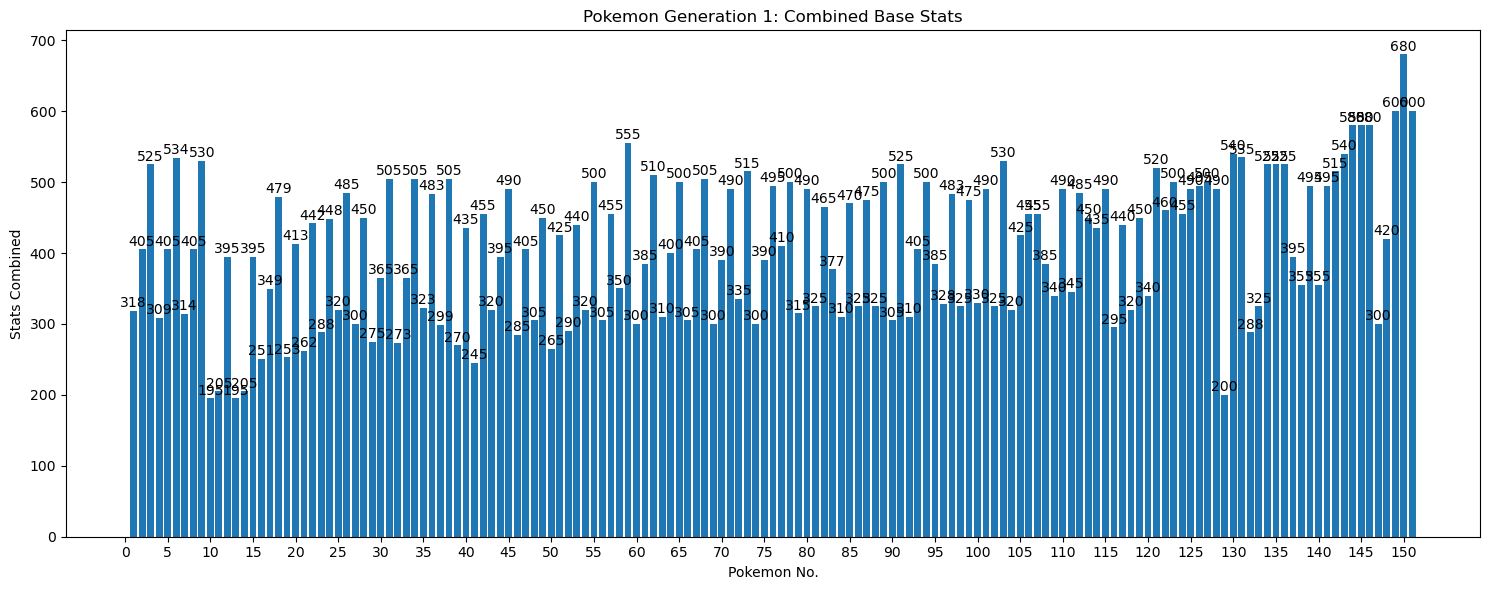


Final Pokemon Dataset Preview:
   Pokemon No.  HP  Attack  Defense  S.Attack  S.Defense  Speed  \
0            1  45      49       49        65         65     45   
1            2  60      62       63        80         80     60   
2            3  80      82       83       100        100     80   
3            4  39      52       43        60         50     65   
4            5  58      64       58        80         65     80   

   Combined Stat  Normalized Combined Stat  
0            318                  0.253608  
1            405                  0.432990  
2            525                  0.680412  
3            309                  0.235052  
4            405                  0.432990  
Table 0:
<tr>
<td align="center" class="fooevo" rowspan="2">
		No.
		</td>
<td align="center" class="fooevo" rowspan="2" width="32">
		Pic	
		</td>
<td align="center" class="fooevo" rowspan="2">
		Name	
		</td>
<td align="center" class="fooevo" rowspan="2">
		Type	
		</td>
<td align="center" cl

In [19]:
# Transformation 6:
# Plot the combined stats by Pokémon No.

plt.figure(figsize=(15, 6))
bars = plt.bar(df['Pokemon No.'], df['Combined Stat'])
plt.xticks(range(0, len(df), 5)) # Show every 5th Pokemon for better readability
plt.xlabel('Pokemon No.')
plt.ylabel('Stats Combined')
plt.title('Pokemon Generation 1: Combined Base Stats')
plt.tight_layout()
# Description: 
# Display of the data transformations via a visual graphic. This is necessary to provide insight into each Pokémon's combined stats in a quick view and will make referencing each Pokémon easier for additional analysis. 

# Annotate bars with values
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1, f"{height}", ha='center', va='bottom')

plt.show()

# Human-readable output
print("\nFinal Pokemon Dataset Preview:")
print(df[['Pokemon No.', 'HP', 'Attack', 'Defense', 'S.Attack', 'S.Defense', 'Speed', 'Combined Stat', 'Normalized Combined Stat']].head())

# Locate the necessary table
tables = soup.find_all('table')
for i, table in enumerate(tables):
    print(f"Table {i}:")
    rows = table.find_all("tr")
    for row in rows[:5]:
        print(row)
    print("\n")

In [20]:
# Section 3

# Transformation 1:
# Filter out unnecessary data

# API base URL
pokeapi_url = "https://pokeapi.co/api/v2/pokemon/"

# Function to fetch Pokémon data
def get_pokemon_data(pokemon_id):
    response = requests.get(f"{pokeapi_url}{pokemon_id}")
    if response.status_code == 200:
        data = response.json()
        return {
        "name": data["name"],
        "types": [t["type"]["name"] for t in data ["types"]],
        "stats": {stat["stat"]["name"]: stat["base_stat"] for stat in data["stats"]}
        }
    else:
        print(f"Failed to retrieve Pokemon {pokemon_id}")
        return None

# Fetch the first 151 Pokémon
pokemon_list = []
for i in range(1, 152): # Pokemon 1 to 151

    pokemon_data = get_pokemon_data(i)
    if pokemon_data:
        pokemon_list.append(pokemon_data)

# Display some of the processed data
print(f"Retrieved {len(pokemon_list)} Pokemon.")
print(pokemon_list[:5]) # Show the first 5 Pokemon

# Description: 
# I requested Pokémon data from the pokeapi.co. I then only extract name, types, and stats from the JSON, as this is what I will need to best answer my project topic.

Retrieved 151 Pokemon.
[{'name': 'bulbasaur', 'types': ['grass', 'poison'], 'stats': {'hp': 45, 'attack': 49, 'defense': 49, 'special-attack': 65, 'special-defense': 65, 'speed': 45}}, {'name': 'ivysaur', 'types': ['grass', 'poison'], 'stats': {'hp': 60, 'attack': 62, 'defense': 63, 'special-attack': 80, 'special-defense': 80, 'speed': 60}}, {'name': 'venusaur', 'types': ['grass', 'poison'], 'stats': {'hp': 80, 'attack': 82, 'defense': 83, 'special-attack': 100, 'special-defense': 100, 'speed': 80}}, {'name': 'charmander', 'types': ['fire'], 'stats': {'hp': 39, 'attack': 52, 'defense': 43, 'special-attack': 60, 'special-defense': 50, 'speed': 65}}, {'name': 'charmeleon', 'types': ['fire'], 'stats': {'hp': 58, 'attack': 64, 'defense': 58, 'special-attack': 80, 'special-defense': 65, 'speed': 80}}]


In [21]:
# Transformation 2:
# Normalize stat values for the first 151 Pokémon

# Extract all base stats
all_stats = {stat: [p["stats"][stat] for p in pokemon_list] for stat in pokemon_list[0]["stats"].keys()}

# Computation for min and max of each base stat
stat_min_max = {stat: (min(values), max(values)) for stat, values in all_stats.items()}

# Normalize stat values
for pokemon in pokemon_list:
    pokemon["normalized_stats"] = {
        stat: round(
            (pokemon["stats"][stat] - stat_min_max[stat][0]) / (stat_min_max[stat][1] - stat_min_max[stat][0]), 2
        )
               for stat in pokemon["stats"]
               }
# Display some of the normalized stats
print(f"Normalized stats for {pokemon_list[0]['name']}: {pokemon_list[0]['normalized_stats']}")

# Description: 
# I pulled the stat values from the pokeapi.co JSON. Then, I rescale the stats from 0 to 1 to make comparisons easier to understand and more readable across Pokémon.


Normalized stats for bulbasaur: {'hp': 0.15, 'attack': 0.34, 'defense': 0.25, 'special-attack': 0.36, 'special-defense': 0.43, 'speed': 0.22}


In [22]:
# Transformation 3:
# Group Pokémon by type

# Dictionary to store Pokémon by type
type_groupings = defaultdict(list)

# Group Pokémon by type
for pokemon in pokemon_list:
    type_1 = pokemon["types"][0] if len(pokemon["types"]) > 0 else "Unknown"
    type_2 = pokemon["types"][1] if len(pokemon["types"]) > 1 else "None" # Handle for mono-type Pokemon

    type_groupings[type_1].append(pokemon)
    if type_2 != "None":
        type_groupings[type_2].append(pokemon) # Add Pokémon to the second typing

# Display some of the grouped Pokémon
for pokemon_type, pokemons in list(type_groupings.items())[:5]: # Show the first 5 Pokemon
    for p in pokemons[:5]: # Limiting output for readbility
        print(f"Pokémon: {p['name'].capitalize()}, Type 1: {p['types'][0]}, Type 2: {p['types'][1] if len(p['types']) > 1 else 'None'}")

# Description: 
# I extract the type data from the JSON of the pokeapi.co. With the type data, I categorize the Pokémon by their types, ensuring to catch Pokémon that have more than 1 type and clearly labeling those that don't.

Pokémon: Bulbasaur, Type 1: grass, Type 2: poison
Pokémon: Ivysaur, Type 1: grass, Type 2: poison
Pokémon: Venusaur, Type 1: grass, Type 2: poison
Pokémon: Oddish, Type 1: grass, Type 2: poison
Pokémon: Gloom, Type 1: grass, Type 2: poison
Pokémon: Bulbasaur, Type 1: grass, Type 2: poison
Pokémon: Ivysaur, Type 1: grass, Type 2: poison
Pokémon: Venusaur, Type 1: grass, Type 2: poison
Pokémon: Weedle, Type 1: bug, Type 2: poison
Pokémon: Kakuna, Type 1: bug, Type 2: poison
Pokémon: Charmander, Type 1: fire, Type 2: None
Pokémon: Charmeleon, Type 1: fire, Type 2: None
Pokémon: Charizard, Type 1: fire, Type 2: flying
Pokémon: Vulpix, Type 1: fire, Type 2: None
Pokémon: Ninetales, Type 1: fire, Type 2: None
Pokémon: Charizard, Type 1: fire, Type 2: flying
Pokémon: Butterfree, Type 1: bug, Type 2: flying
Pokémon: Pidgey, Type 1: normal, Type 2: flying
Pokémon: Pidgeotto, Type 1: normal, Type 2: flying
Pokémon: Pidgeot, Type 1: normal, Type 2: flying
Pokémon: Squirtle, Type 1: water, Type 2:

In [23]:
# Transformation 4:
# Handle missing or outlier data

# Identify missing stats
missing_entries = [p["name"] for p in pokemon_list if None in p["stats"].values()]
print(f"Pokémon with missing stats: {missing_entries}")

# Compute thresholds for outlier detections
stat_values = {stat: [p["stats"][stat] for p in pokemon_list] for stat in pokemon_list[0]["stats"].keys()} 
stat_means = {stat: np.mean(values) for stat, values in stat_values.items()}
stat_std_devs = {stat: np.std(values) for stat, values in stat_values.items()}

# Flag outliers using z-score threshold
outliers = {
    stat: [
        {
            "name": p["name"],
            "types": ", ". join(p["types"]), # Formatting for readbility
            "stat_value": p["stats"][stat],
            "z_score": round((p["stats"][stat] - stat_means[stat]) / stat_std_devs[stat], 2)
        }
        for p in pokemon_list if abs(p["stats"][stat] - stat_means[stat]) > 3 * stat_std_devs[stat]
    ]
    for stat in stat_values.keys()
}

# Show flagged outliers
for stat, pokemon_data in outliers.items():
    print(f"\nOutliers in {stat}:")
    for p in pokemon_data:
        print(f"Pokémon: {p['name'].capitalize()}, Type(s): {p['types']}, {stat}: {p['stat_value']}, Z-score: {p['z_score']}")

# Description: 
# I process the stats from the pokeapi.co JSON to account for missing or extreme values. The output also specifically names the Pokémon, its type(s), which specific stat is the outlier, and the Z-score to describe how significantly it differs from the average. 


Pokémon with missing stats: []

Outliers in hp:
Pokémon: Chansey, Type(s): normal, hp: 250, Z-score: 6.52
Pokémon: Snorlax, Type(s): normal, hp: 160, Z-score: 3.36

Outliers in attack:

Outliers in defense:
Pokémon: Cloyster, Type(s): water, ice, defense: 180, Z-score: 4.17
Pokémon: Onix, Type(s): rock, ground, defense: 160, Z-score: 3.42

Outliers in special-attack:
Pokémon: Mewtwo, Type(s): psychic, special-attack: 154, Z-score: 3.05

Outliers in special-defense:

Outliers in speed:
Pokémon: Electrode, Type(s): electric, speed: 150, Z-score: 3.0


In [24]:
# Transformation 5:
# Calculate aggregates and prepare for visualization

# Compute the average stats per type
type_averages = {}

for poke_type, pokemons in type_groupings.items():
    stat_sums = {stat: sum(p["stats"][stat] for p in pokemons) for stat in pokemons[0]["stats"].keys()}
    stat_avgs = {stat: round(stat_sums[stat] / len(pokemons), 2) for stat in stat_sums}
    type_averages[poke_type] = stat_avgs

# Show the results
for poke_type, stats in list(type_averages.items())[:5]: # Limiting output for readbility
    print(f"\nType: {poke_type} \nAverage Stats")
    for stat, avg in stats.items():
        print(f"{stat.capitalize()}: {avg}")

# Description: 
# I calculate sums and averages from the pokeapi.co JSON, specifically Pokémon stats. The output organizes the aggregated values by type and displays the specific averages for easy comparison between types.

# Human readable dataset after all transformations

stat_categories = ["hp", "attack", "defense", "special-attack", "special-defense", "speed"]

# Min-max normalization for each stat
for stat in stat_categories:
    stat_values = [p["stats"][stat] for p in pokemon_list if stat in p["stats"]]

    # Find the min and max values for normalization
    min_val, max_val = min(stat_values), max(stat_values)

    # Apply normalization and assign to each Pokémon
    for p in pokemon_list:
        if stat in p["stats"]: # Check to ensure Pokémon has the stat before modification
            normalized_value = (p["stats"][stat] - min_val) / (max_val - min_val)
            if "normalized_stats" not in p:
                p["normalized_stats"] = {} # Normalized stats dictionary if missing
            p["normalized_stats"][stat] = round(normalized_value, 2) # Assign the normalized stats
        
# Structured dataset with each relevant field
final_data = []
for p in pokemon_list:
    if "normalized_stats" not in p:
        continue # Skip Pokémon missing normalized stats

    formatted_stats = {stat: p["normalized_stats"].get(stat, "N/A") for stat in stat_categories}
    
    # Find stats where a Pokémon is flagged as an outlier
    outlier_stats = [
        stat for stat in outliers if p["name"] in [o["name"] for o in outliers[stat]]
    ]

    final_data.append({
        "Name": p["name"].capitalize(),
        "Type 1": p["types"][0],
        "Type 2": p["types"][1] if len(p["types"]) > 1 else "None",
        **formatted_stats,
        "Outlier Stats": ", ".join(outlier_stats) if outlier_stats else "None"
    })

# Conversion to Pandas DataFrame for readability
df = pd.DataFrame(final_data)

# Show human readable dataset
print(df.head())


Type: grass 
Average Stats
Hp: 62.5
Attack: 72.36
Defense: 69.29
Special-attack: 82.86
Special-defense: 65.36
Speed: 48.57

Type: poison 
Average Stats
Hp: 60.55
Attack: 67.88
Defense: 59.33
Special-attack: 68.64
Special-defense: 64.33
Speed: 61.91

Type: fire 
Average Stats
Hp: 63.83
Attack: 83.92
Defense: 62.58
Special-attack: 84.58
Special-defense: 76.67
Speed: 84.0

Type: flying 
Average Stats
Hp: 68.26
Attack: 85.42
Defense: 66.42
Special-attack: 69.16
Special-defense: 70.47
Speed: 85.74

Type: water 
Average Stats
Hp: 62.56
Attack: 70.69
Defense: 80.94
Special-attack: 66.88
Special-defense: 65.59
Speed: 66.28
         Name Type 1  Type 2    hp  attack  defense  special-attack  \
0   Bulbasaur  grass  poison  0.15    0.34     0.25            0.36   
1     Ivysaur  grass  poison  0.21    0.44     0.33            0.47   
2    Venusaur  grass  poison  0.29    0.60     0.45            0.61   
3  Charmander   fire    None  0.12    0.36     0.22            0.32   
4  Charmeleon   fire 

In [25]:
# Load my 3 cleaned and transformed datasets into a database using SQLite.

conn = sqlite3.connect("pokemon.db")
cursor = conn.cursor()

# Confirm creation of pokemon.db
print("pokemon.db was created.")

# Load each into SQLite as an individual table, join the datasets together with SQL joins into 1 dataset.

pokemon.db was created.
